In [1]:
print("hello world")

hello world


In [2]:
import pandas as pd

from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import DataLoader,Dataset
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [3]:
# checking for gpu
device=torch.device("mps")
print(f"using device: {device}")

using device: mps


In [4]:
df=pd.read_csv("fashion-mnist_train.csv.zip")

In [5]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
df.shape

(60000, 785)

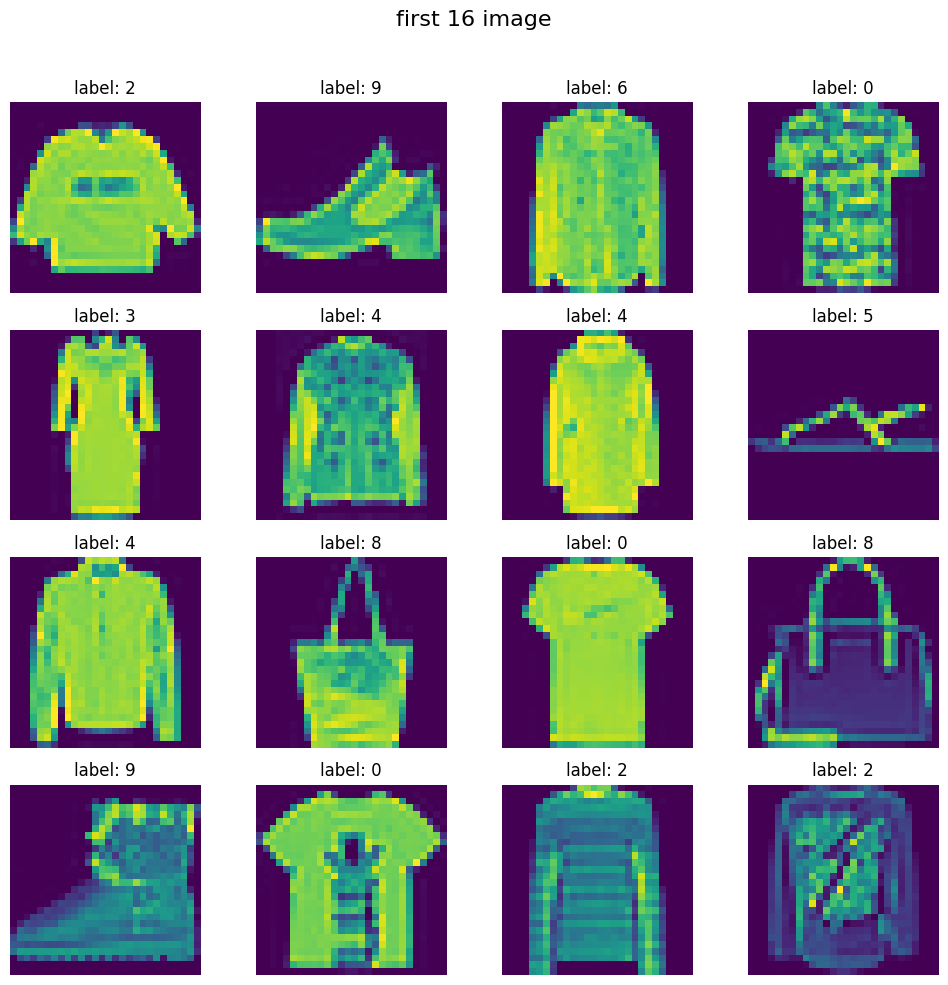

In [7]:
# creating a 4*4 grid to show image 

fig, axes=plt.subplots(4,4,figsize=(10,10))
fig.suptitle("first 16 image",fontsize=16)

# plot the first 16 image of the data
for i,ax in enumerate(axes.flat):
    img=df.iloc[i,1:].values.reshape(28,28)
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"label: {df.iloc[i,0]}")

# arjusting layout to fit the title
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()


In [8]:
x=df.iloc[:,1:]
y=df.iloc[:,0]

In [9]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [10]:
x_train=x_train/255.0
x_test=x_test/255.0

In [15]:
class Customdataset(Dataset):
    def __init__(self,features,labels):
        self.features=torch.tensor(features.values,dtype=torch.float32).reshape(-1,1,28,28)
        self.labels=torch.tensor(labels.values,dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        return self.features[index],self.labels[index]
    

In [16]:
train_dataset=Customdataset(x_train,y_train)
test_dataset=Customdataset(x_test,y_test)

In [19]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True,pin_memory=True)
test_loader=DataLoader(test_dataset,batch_size=32,shuffle=True,pin_memory=True)

In [30]:
class MyCnn(nn.Module):
    def __init__(self,input_features):
        super().__init__()

        self.features=nn.Sequential(
            nn.Conv2d(input_features, 32, kernel_size=3 ,padding="same" ),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(kernel_size=2,stride=2),

            nn.Conv2d(32, 64, kernel_size=3 ,padding="same" ),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(kernel_size=2,stride=2)
        )

        self.classifier=nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7,128),
            nn.ReLU(),
            nn.Dropout(p=0.4),
            
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Dropout(p=0.4),
            nn.Linear(64,10)
        )

    def forward(self,x):
        x=self.features(x)
        x=self.classifier(x)
        return x


In [28]:
learning_rate=0.01
epochs=100

In [31]:
model=MyCnn(1)
model.to(device)
criterion=nn.CrossEntropyLoss()
optimizer=optim.SGD(model.parameters(),lr=learning_rate,weight_decay=1e-4)

In [32]:
for epoch in range(epochs):
    total_epoch_loss=0
    for batch_features,batch_labels in train_loader:
        batch_features,batch_labels=batch_features.to(device),batch_labels.to(device)

        outputs=model(batch_features)
        loss=criterion(outputs,batch_labels)

        #back pass
        optimizer.zero_grad()
        loss.backward()

        # upgrade grads
        optimizer.step()

        total_epoch_loss=total_epoch_loss+loss.item()
    avg_loss=total_epoch_loss/len(train_loader)
    print(f"epoch: {epoch+1},loss {avg_loss}")


/Users/keshavmacbook/Projects/AI-ML/AI-ML basic/.aiml-venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


epoch: 1,loss 0.6539884080390136
epoch: 2,loss 0.3802023478746414
epoch: 3,loss 0.32451924614608285
epoch: 4,loss 0.28806377147013945
epoch: 5,loss 0.26234204548969864
epoch: 6,loss 0.24428897626077137
epoch: 7,loss 0.22679504769171277
epoch: 8,loss 0.21026442747066418
epoch: 9,loss 0.19992862716379264
epoch: 10,loss 0.18815939271698395
epoch: 11,loss 0.1770984580181539
epoch: 12,loss 0.16594265945504108
epoch: 13,loss 0.1586215129463623
epoch: 14,loss 0.14796826805857322
epoch: 15,loss 0.13816862872770677
epoch: 16,loss 0.1344995805816725
epoch: 17,loss 0.12859824040159584
epoch: 18,loss 0.11885087638053422
epoch: 19,loss 0.11411201920701812
epoch: 20,loss 0.1078107502188844
epoch: 21,loss 0.10423867771805574
epoch: 22,loss 0.09729926946604003
epoch: 23,loss 0.09138608099198124
epoch: 24,loss 0.08958969012911742
epoch: 25,loss 0.08565880659701845
epoch: 26,loss 0.08191794995001207
epoch: 27,loss 0.0754522014374379
epoch: 28,loss 0.0727805573133713
epoch: 29,loss 0.07354405835638075
ep

In [33]:
# evaluation on test data
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in test_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.9205


In [34]:
# evaluation on training data
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in train_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.9957083333333333
